In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [3]:
#reading our data set
df = pd.read_csv('../data/ufo_sightings_scrubbed.csv')

df['duration (seconds)'] = pd.to_numeric(
    df['duration (seconds)'],
    errors='coerce'
)

#checking first 10 outputs of dataframe
df.head(10)

C:\Users\foxyh\AppData\Local\Temp\ipykernel_16764\3033478798.py:2: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/ufo_sightings_scrubbed.csv')


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300.0,5 minutes,My father is now 89 my brother 52 the girl wit...,2007-04-27,36.595,-82.188889
6,1965-10-10 21:00:00,penarth (uk/wales),NaN,gb,circle,180.0,about 3 mins,penarth uk circle 3mins stayed 30ft above m...,2006-02-14,51.434722,-3.180000
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200.0,20 minutes,A bright orange color changing to reddish colo...,1999-10-02,41.1175,-73.408333
8,1966-10-10 20:00:00,pell city,al,us,disk,180.0,3 minutes,Strobe Lighted disk shape object observed clos...,2009-03-19,33.5861111,-86.286111
9,1966-10-10 21:00:00,live oak,fl,us,disk,120.0,several minutes,Saucer zaps energy from powerline as my pregna...,2005-05-11,30.2947222,-82.984167


In [4]:
#list of column names
df.columns

Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'duration (hours/min)', 'comments', 'date posted', 'latitude',
       'longitude '],
      dtype='object')

In [5]:
#checking data types and NaN
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80329 non-null  float64
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80332 non-null  object 
 10  longitude             80332 non-null  float64
dtypes: float64(2), object(9)
memory usage: 6.7+ MB


In [6]:
#checking for missing values (NaN)
df.isna().sum()

datetime                   0
city                       0
state                   5797
country                 9670
shape                   1932
duration (seconds)         3
duration (hours/min)       0
comments                  15
date posted                0
latitude                   0
longitude                  0
dtype: int64

In [7]:
#lets see which countries are involved
df['country'].value_counts()

#let's look at the states
df['state'].value_counts()

#let's look at the shapes of uap's
df['shape'].value_counts()

shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
delta            7
round            2
crescent         2
pyramid          1
flare            1
hexagon          1
dome             1
changed          1
Name: count, dtype: int64

In [8]:
#find out the number of different shapes we have
len(df['shape'].unique())

#show unique shaped
df['shape'].unique()

array(['cylinder', 'light', 'circle', 'sphere', 'disk', 'fireball',
       'unknown', 'oval', 'other', 'cigar', 'rectangle', 'chevron',
       'triangle', 'formation', nan, 'delta', 'changing', 'egg',
       'diamond', 'flash', 'teardrop', 'cone', 'cross', 'pyramid',
       'round', 'crescent', 'flare', 'hexagon', 'dome', 'changed'],
      dtype=object)

In [9]:
#lets check for duplications
df.duplicated(keep = False).sum()

0

In [11]:
#converting into a datetime column 
df['datetime'] = pd.to_datetime(df['datetime'])

#making a variable of year counts
year_counts = df.groupby(df['datetime'].dt.year).size()

In [12]:
#making a variable for the shapes
shape_count = df['shape'].value_counts()

Text(0, 0.5, 'Count')

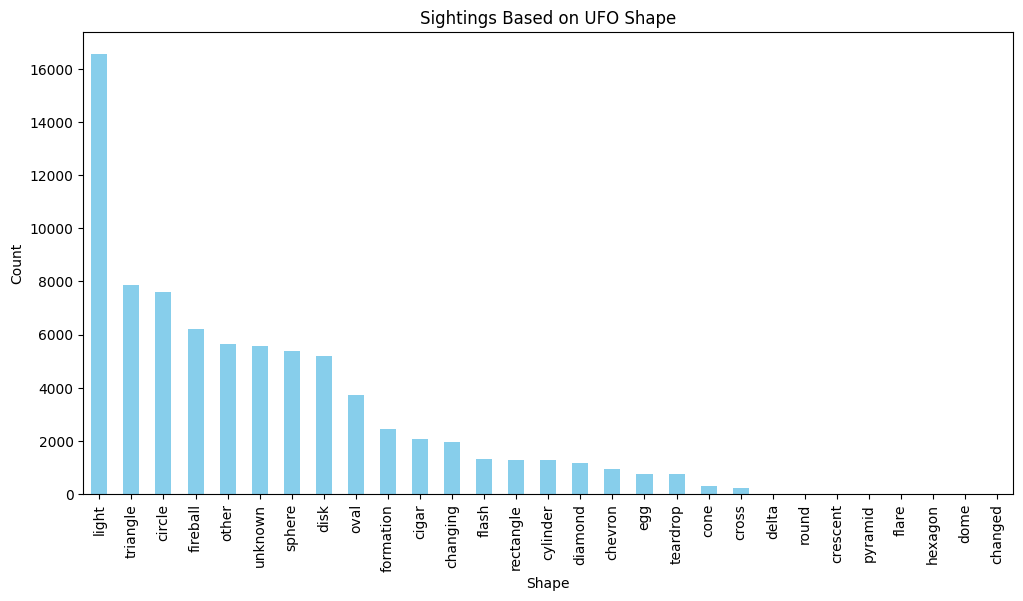

In [14]:
plt.figure(figsize=(12,6))

#plotting
shape_count.plot(kind='bar', color='skyblue')

plt.title('Sightings Based on UFO Shape')
plt.xlabel('Shape')
plt.ylabel('Count')


This is a bar graph depicting the recorded number of sightings based off the UFO's shape. This type of graph allows us to observe the quantity of one shape to another by allowing us to visualize the volume in a bar. It is allows us to ask which type of ufo by its shape is most commonly noticed. 

There is an issue with this particular graph which I will need to adress however my sills are not up to par yet. Despite properly cleaning duplicated rows of data (rows which were the exact duplicate of another), I have not been able to take in account weather the sighting itself was a duplicate or not. The reason i bring this up is the following: If a UFO is more visible for one reason or another, weather it is shape, color, or other physical properties, More than one individual may notice the event and more than one individual may report said event. 

To get a more precise depiction of the number of UFO's themselves, I would like to utilize a function known as reverse_geocoding. I have not been able to successfully make this function work because of cleaning the latitude and longitude columns has been turning out to be a much larger endevour then I initially realized. However this still provides vital information to us. Getting this code to work would be crucial in being able to group a siting based off its location, time, and shape, possibly eliminating several reports as a multiple reported sighting and prevent us from assuming a larger volume of a particular shape based of the number of sightings. In short, number of sightings does not equate to number of entities, just a potential increase of visibility. This hypothesis will need further testing.

It suggests the shape or properties themselves have been noticed more frequently depending on the shape category. 
In a hypothetical scenario of national security, if these UFOs or UAPs are of our governments own design and are rather secret testings of survalience aricraft we dont wish our public to know about for national security reasons, it would hel give us insight on concealment concerns.

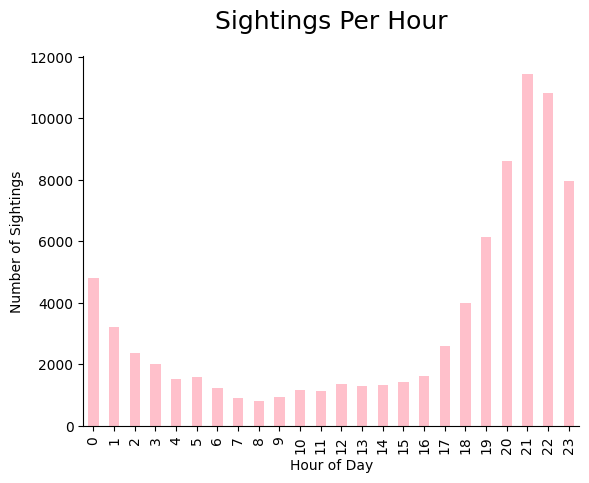

In [88]:
#hourly count
hourly_counts = df.groupby(df["datetime"].dt.hour).size()

hourly_counts.plot(kind='bar', color = "pink")


plt.xlabel("Hour of Day")
plt.ylabel("Number of Sightings")
plt.title("Sightings Per Hour", fontsize = 18, pad=20)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)




This is a bar graph depicting the number of sightings being reported based on the hour of day. It further elaborates on the idea of visibility posed in the previous graph. If light based UFOs, or UAPs if you may, are reported more frequently, it can be assumed that they are more visible at night than durring the day, especially when compared to aerial phenomina of other shapes. 

I am a person who enjoys, and quiet frankly desires the idea of something bigger than us, however i must refrane from my bias and approach with a level of skepticism. Light, despite having properties of both waves and particles, I.E. lightwaves and photons, is a relatively intangible object. That is to be said, the visual occurance of a light based object doesnt conclude that the object is there, just a visualiztion of light particles themselves.

It is at this time I pose the inquiry of what a "light" shape could represent? In some underground, dark web conspiracy circles, these could be crafts of higher dimensional beings. A being of a higher dimension would appear to be many shapes, colors, spectrums simultaneously within our 3 dimensional existance. Forinstance if a 3d sphere passed through a 2 dimensional world, it would appread as a point, that grows until the circle which represents the spheres circumference reaches its maximum then shrinks back to a point. These types of hypothesi became more prominante folling the mathematician, Bernhard Riemanns address of higher dimensional geometry. This same geometry led to tensor flows and other high level physics applications that laid the foundations for relativity and quantum applications.

On a seperate note, light can be observed as a projection from a source. A similar and more recent developement is focused light projection. Specifically Light Amplification by Stimulated Emission of Radiation, or laser for short. Aside from the unrealistic common thought of sci-fi driven laser pulse rifles that can cut through steal, lasers are often times used to communication and survey. Though the beam is mostly invisible until it touches a surface, most of us have seen them in fog or smoke reflecting off of thousands of particles. I pose the hypothetical scenario that perhaps these veiwings of light shaped UFOs are actually the refraction of light from cloud formations, or partical build up in the atmosphere from a seperate source, perhaps a foreign military drone using a laser to gauge distances, temperatures, etc of our nations infulstructure.

Another aspect i wish to pursue after figuring out how to make reverse_geocoding work is to load a known database of our air fields, airbases, and power plants. This is important because if there is a correlation to these light based phenome being spotted near these cruicial infulstructure, it could be a red flag of foreing adversaries spying on us.

In [89]:
non_light = len(df[df['shape'] != 'light'])
light_total = len(df[df['shape'] == 'light'])

labels=['Non light base uaps', "light based UAPs"]

counts = [f"{non_light}", f"{light_total}"]

In [46]:
non_light

63767

In [47]:
light_total

16565

In [48]:
counts

['63767', '16565']

<Figure size 800x800 with 0 Axes>

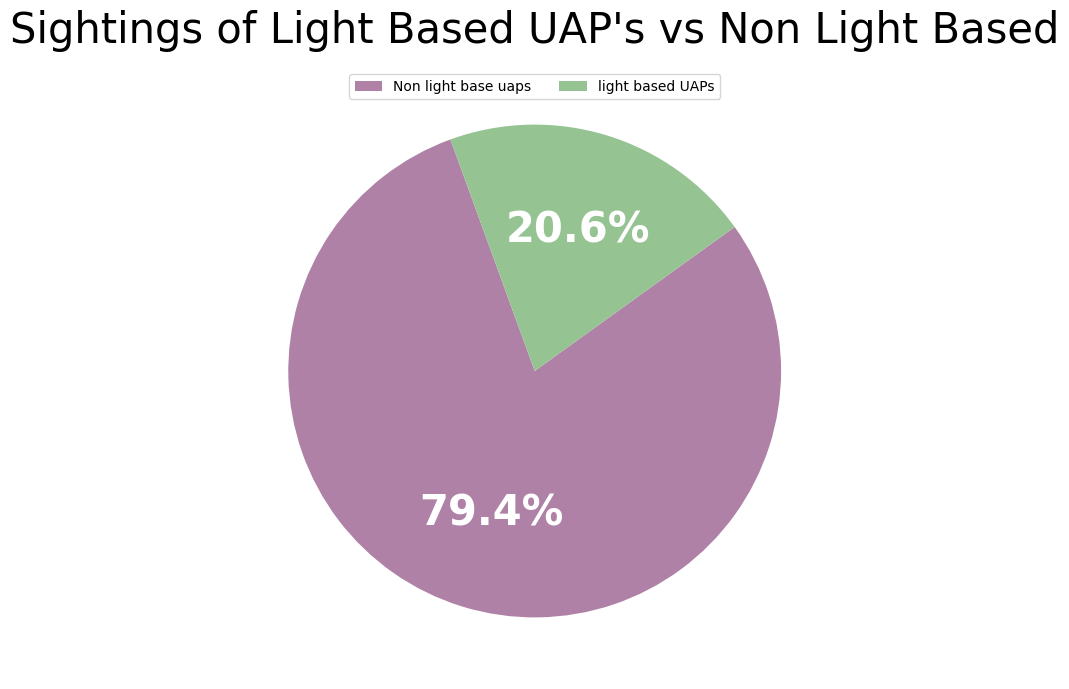

In [58]:
plt.figure(figsize=(8,8))

#lets make a pie chart
fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    counts,
    startangle=110,
    colors=["#af81a7","#95c492"],
    autopct="%1.1f%%")

ax.set_title(
    "Sightings of Light Based UAP's vs Non Light Based",
    fontsize=30,
    pad=15,
    loc="center")

for autotext in autotexts:
    autotext.set_fontsize(30)
    autotext.set_color("white")
    autotext.set_weight('bold')


ax.legend(
   wedges,
   labels,
   loc="lower center",
   bbox_to_anchor = (0.5, 0.93),
   ncol=2
   )

plt.show()

This pie chart simples conveys the proportions of light based UFO's to those that are not. Despite being nearly a fifth of the reported sightings, there is still a large amount of other craft shape being reported. 

At some point it would be wise to try to find a visualization of when each shape is most frequently spotted and reported. Answering this question could help understand weather there are more craft going unoticed at night due to lack of visibility. 
 
The most important aspect of this graph is that it shows a larger faction of doubt for dismissing the light based shapes as novel sightings as previously stated in the inquries and hypothesi of the last couple of sections. It spurs the need for further research and refinement of questioning.

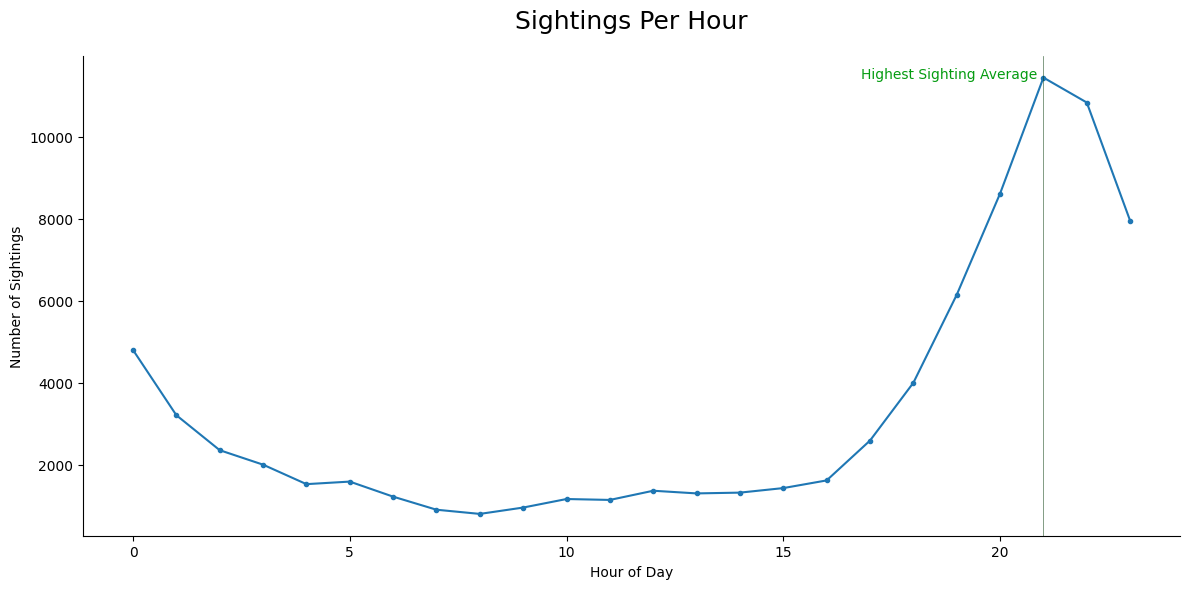

In [90]:
plt.figure(figsize=(12,6))

hourly_counts = df.groupby(df['datetime'].dt.hour).size().reindex(range(24), fill_value=0)
hourly_counts.plot(kind='line', marker = '.' )


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(
    21,
    color = '#063b0a',
    linewidth = 0.5,
    alpha = 0.7
)

ax.text(
    16.8,
    max(hourly_counts),
    "Highest Sighting Average",
    color = "#059c11",
    fontsize = 10
)




plt.xlabel("Hour of Day")
plt.ylabel("Number of Sightings")
plt.title("Sightings Per Hour", fontsize = 18, pad=20)

plt.tight_layout()
plt.show()

This is a line chart of the sightings by hour of the day. It is helpful for us to see when the rate (slope of a line) begins to increase and decrease. It shows that at around 16:00 hours (4pm) there begins an increase in the number of sightings by hour of the day with a maximum number of sightings at 21:00 hours (9pm). This suggests that sightings pick up durring the evening hours. 

We need to ask ourselvs if there is an increase in activity at these hours of the UFOs or could we explain this by an increase in veiwers at these given times. I pose the concept of work schedules. Many individuals leave work at around 3-4pm, roughly when the increase in sightings occur. A way we can check this theory is by a statistical analysis of unemployement rates with population size, in conjuntion with the day of the week sightings were reported. This would simply give us insight weather or not the increase in sightings is due to people being active outside or an increase in the crafts themselves. Still, it may not be a definitive correlation.

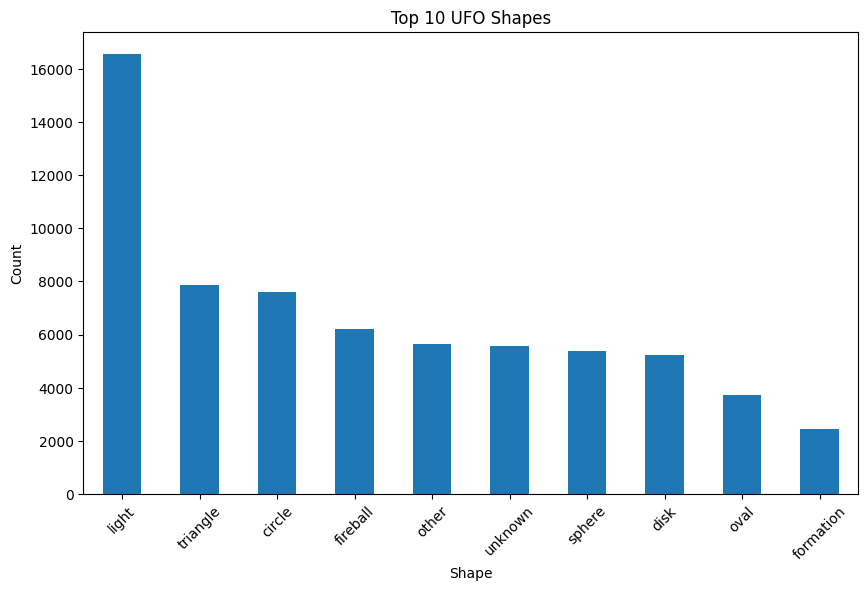

In [91]:
shape_counts = df['shape'].value_counts().head(10)

plt.figure(figsize=(10,6))
shape_counts.plot(kind='bar')

plt.title('Top 10 UFO Shapes')
plt.xlabel('Shape')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

This is a bar graph of the top 10 ufo shapes. This graph allows us to view a condensed version of the more popular UFOs or UAPs being spotted and reported. This helps us cut out instances where a single recording of flare, hexagon, dome, or changing for example have occured. These that where eliminated from the graph for low occurances most likely can fall into another more precise category. 

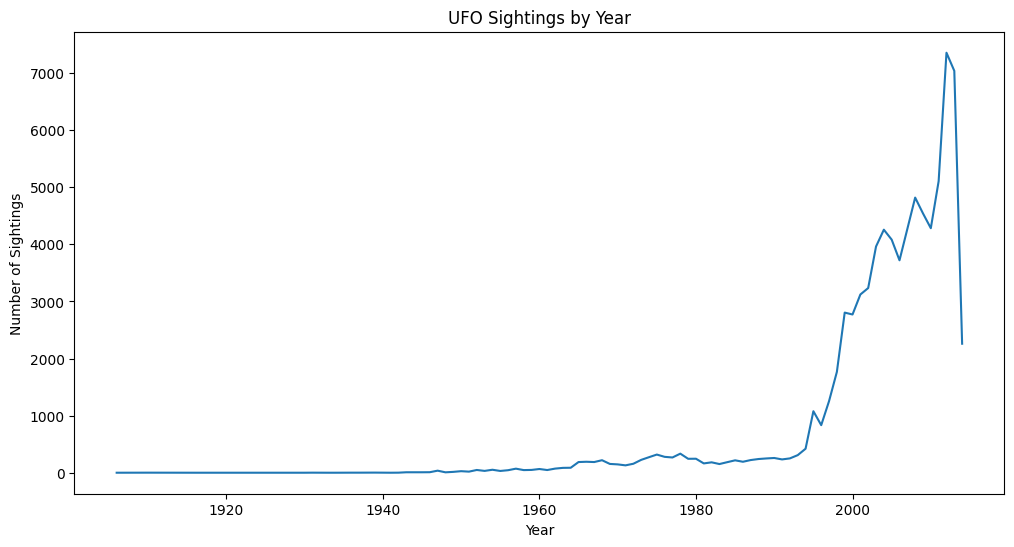

In [76]:
df['year'] = df['datetime'].dt.year

sightings_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(sightings_per_year.index, sightings_per_year.values)

plt.title('UFO Sightings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Sightings')

plt.show()

This is a line graph showing the sightings by year. It helps us understand the trend and time in which reports began and picked up. This graph can help get insight to several possible factors. We notice that there has been an increase at a very slight rate in the 1940s. It would behoove us to talk a bit about the zeitghiest at key times of this chart to possibly explain this trend.

1947, Roswell, New Mexico, is one of the most notorious UFO incidents in history. as we can see there are minute ripples in our line since that date. This could suggest that more people have become more alert, or paranoid, or dilusional, since the release of that particular news article. Regardless, this is when the sighting began to make a climb. It can be noted that there is not a large spike in these sightings. That being said, referring back to the zeitgheist (or spirit of the times) the 1940s 50s and 60s were not generally kind to people with mental illnesses. There is a large stigma, especially around those times for such things, and being labeled a quack could be very socially detrimental, causing reports to be heavily supressed. There also needs to be mention of communication. These eras, phone communication and the internet or lack there of, were not as readily avalible as they are now.

We see a steady increase until the mid to lates 19060s. Post WWII, the cold war with Russia began. This decades long era was heightened in the early 1960s durring the cuban missle crisis with notible accolades of the space race being Russias succeful deployment of the first satelite sputnic happening in the year of 1957. Major events of the Russian and American space race durring this cold war erra not only included sputnick in 1957 but JFK declaring that the americans will be the first on the moon back in 1961. Other noteable events include astronuaghts and comsonaughts performing various feats in space from 1960s to the 1970s with 1969 being the year of the moon landing, wrapping up in 1975 with the Apollo-Soyus test project that pairs american and societ spacecraft in orbit symbolizing the offical end of the space race. Why is this important? By looking at our graph we can see an inconsistency with the steady rise spurring from the 1940s to that date. Specifically with peaks relatively near those major miles stones. The space race was an international competition which americans and russian nationalists were for a large part all concerned with. This was the apex of entertainment on the news and radio during the time, and when conspiracy theories began to really emerge along with various propoganda attempting to disued one anothers populus. We can see as tensions between these two nations lowered, so did the rate of observations.

Now we address the elephant in the room. With most naturally occuring growths in nature, they follow a hyperbolic trend of growth that levels out or hit a critical point. Looking at this graph we notice a steady trend for the most part, aside from ripples that are possibly explained by paranoi spurred by the height of the space race of the cold war. However, we notice a sharp and drastic increase in the 90s. We must ask ourselves what could have possibly initiated this. Maybe, the rapid mainstream adoption of the internet. The mid 90s was a technological boom with Google being founded in 1995, there were politcal scandals including Bill clinton, and national trgedies like The oklahoma city bombings. We must ask ourselves with the stimulation of the internet, political scandals, and violent activism, could a heightened sense of population parinoa be responsible for the increase of sightings reported? Perhaps it was the amount of cell phones people had at the tie compared to land lines and lesser technologies that prevented immediate reports. Maybe it was the internet and a search engine known as Google that allowed people who once did not know how to report such observations now having access to a source. 



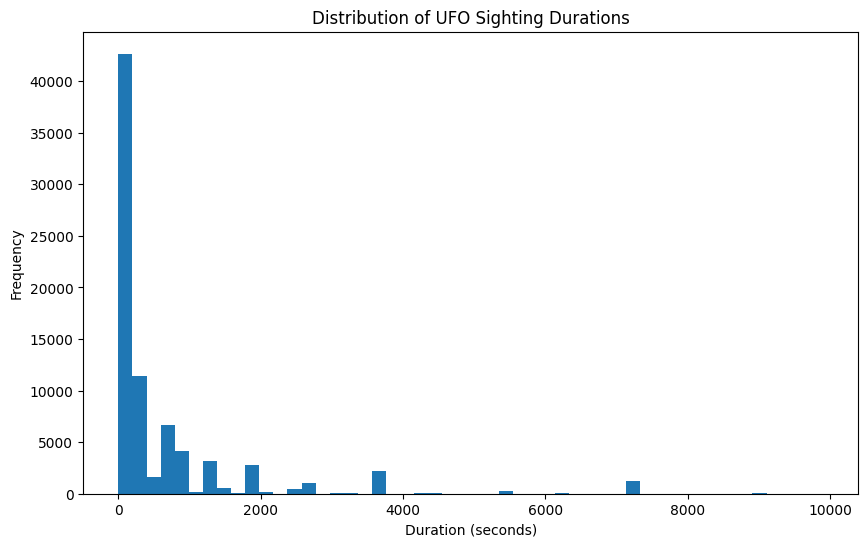

In [92]:
plt.figure(figsize=(10,6))

# Remove extreme outliers
filtered_duration = df[df['duration (seconds)'] < 10000]

plt.hist(filtered_duration['duration (seconds)'].dropna(), bins=50)

plt.title('Distribution of UFO Sighting Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')

plt.show()

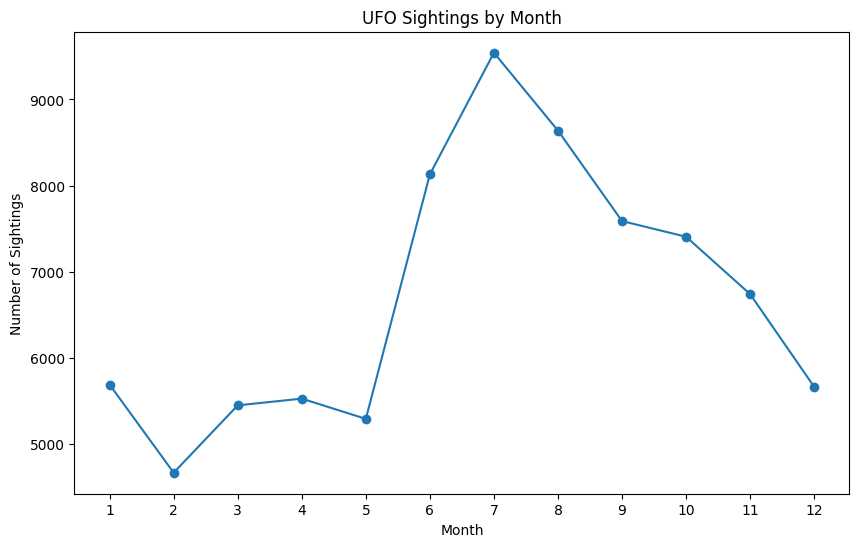

In [93]:
# Create month column

df['month'] = df['datetime'].dt.month

monthly_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')

plt.title('UFO Sightings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')

plt.xticks(range(1,13))
plt.show()

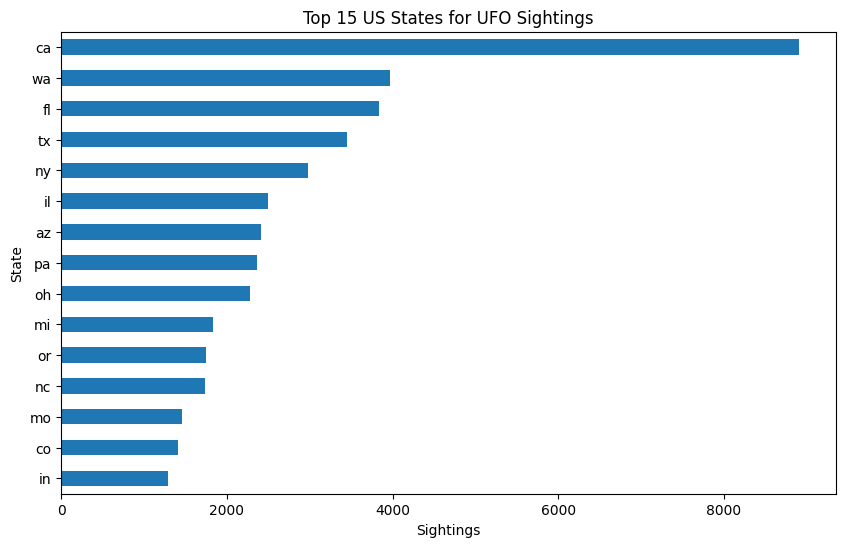

In [94]:
us_data = df[df['country'] == 'us']

state_counts = us_data['state'].value_counts().head(15)

plt.figure(figsize=(10,6))
state_counts.sort_values().plot(kind='barh')

plt.title('Top 15 US States for UFO Sightings')
plt.xlabel('Sightings')
plt.ylabel('State')

plt.show()